In [1]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.utils import dataset_to_policy_features
import tree
import json

/mnt/shared/haitongma/envs/lerobot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_id = "HuggingFaceVLA/libero"
dataset_metadata = LeRobotDatasetMetadata(dataset_id)
metadata_shape = tree.map_structure(lambda x: x.shape if hasattr(x, 'shape') else None, dataset_metadata.stats)
print(json.dumps(metadata_shape, indent=2))

features = dataset_to_policy_features(dataset_metadata.features)

print(features.keys())


{
  "frame_index": {
    "min": [
      1
    ],
    "max": [
      1
    ],
    "mean": [
      1
    ],
    "std": [
      1
    ],
    "count": [
      1
    ],
    "q01": [
      1
    ],
    "q10": [
      1
    ],
    "q50": [
      1
    ],
    "q90": [
      1
    ],
    "q99": [
      1
    ]
  },
  "action": {
    "min": [
      7
    ],
    "max": [
      7
    ],
    "mean": [
      7
    ],
    "std": [
      7
    ],
    "count": [
      1
    ],
    "q01": [
      7
    ],
    "q10": [
      7
    ],
    "q50": [
      7
    ],
    "q90": [
      7
    ],
    "q99": [
      7
    ]
  },
  "observation.images.image": {
    "min": [
      3,
      1,
      1
    ],
    "max": [
      3,
      1,
      1
    ],
    "mean": [
      3,
      1,
      1
    ],
    "std": [
      3,
      1,
      1
    ],
    "count": [
      1
    ],
    "q01": [
      3,
      1,
      1
    ],
    "q10": [
      3,
      1,
      1
    ],
    "q50": [
      3,
      1,
      1
    ],
    "q

In [5]:
dataset2_id = "lerobot/svla_so101_pickplace"
dataset2_metadata = LeRobotDatasetMetadata(dataset2_id)
print(dataset2_metadata.stats)
features2 = dataset_to_policy_features(dataset2_metadata.features)

{'timestamp': {'min': array([0.]), 'max': array([10.16666667]), 'mean': array([4.02786945]), 'std': array([2.41130587]), 'count': array([11939])}, 'frame_index': {'min': array([0]), 'max': array([305]), 'mean': array([120.83608342]), 'std': array([72.33917597]), 'count': array([11939])}, 'observation.images.up': {'min': array([[[0.]],

       [[0.]],

       [[0.]]]), 'max': array([[[1.]],

       [[1.]],

       [[1.]]]), 'mean': array([[[0.60561989]],

       [[0.61367857]],

       [[0.6204704 ]]]), 'std': array([[[0.14559643]],

       [[0.14426887]],

       [[0.14010256]]]), 'count': array([5000])}, 'observation.images.side': {'min': array([[[0.        ]],

       [[0.00392157]],

       [[0.        ]]]), 'max': array([[[1.]],

       [[1.]],

       [[1.]]]), 'mean': array([[[0.49313346]],

       [[0.49096047]],

       [[0.48052104]]]), 'std': array([[[0.16391543]],

       [[0.16801982]],

       [[0.17635921]]]), 'count': array([5000])}, 'observation.state': {'min': array([-

In [12]:
sample.keys()

dict_keys(['observation.images.image', 'observation.images.image2', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])

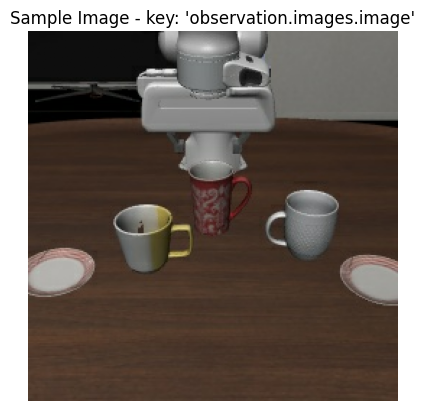

Language instruction: put the white mug on the left plate and put the yellow and white mug on the right plate


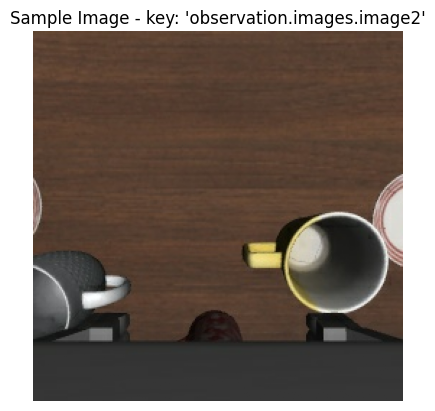

Language instruction: put the white mug on the left plate and put the yellow and white mug on the right plate


In [5]:
import matplotlib.pyplot as plt

# Instantiate dataset (using first dataset and default config)
dataset = LeRobotDataset(dataset_id)
sample = dataset[0]  # sample returns a flat dictionary with keys like 'observation.images.xxx'

# Display a sample image
image_keys = []
for k, v in sample.items():
    if not k.startswith("observation"):
        continue
    val = v[0] if isinstance(v, (list, tuple)) else v
    if hasattr(val, "shape") and len(val.shape) == 3:
        image_keys.append(k)
        

for image_key in image_keys:
    if image_key is not None:
        img = sample[image_key]
        if isinstance(img, (list, tuple)):
            img = img[0]
        plt.imshow(img.permute(1, 2, 0) if hasattr(img, "permute") else img)
        plt.title(f"Sample Image - key: '{image_key}'")
        plt.axis('off')
        plt.show()
    else:
        print("No image observation found in sample.")

    # Show language instruction if present
    language_instruction = sample.get('task', sample.get('language_instruction', None))
    if language_instruction is not None:
        print("Language instruction:", language_instruction)
    else:
        print("No language instruction found in sample.")

In [21]:
dataset.meta.tasks

,task_index
put the white mug on the left plate and put the yellow and white mug on the right plate,0
put the white mug on the plate and put the chocolate pudding to the right of the plate,1
put the yellow and white mug in the microwave and close it,2
turn on the stove and put the moka pot on it,3
put both the alphabet soup and the cream cheese box in the basket,4
put both the alphabet soup and the tomato sauce in the basket,5
put both moka pots on the stove,6
put both the cream cheese box and the butter in the basket,7
put the black bowl in the bottom drawer of the cabinet and close it,8
pick up the book and place it in the back compartment of the caddy,9


In [ ]:
import pandas as pd

episodes = dataset.meta.episodes
ep_df = pd.DataFrame({
    "episode_index": episodes["episode_index"],
    "task": [t[0] if isinstance(t, list) else t for t in episodes["tasks"]],
})
print(ep_df.to_string(index=False))

In [18]:
# Show all task indexes and their corresponding task strings
# dataset.meta.tasks is a DataFrame indexed by task string with a task_index column
for task_str, row in dataset.meta.tasks.iterrows():
    print(f"{int(row['task_index'])}: {task_str}")
    

0: put the white mug on the left plate and put the yellow and white mug on the right plate
1: put the white mug on the plate and put the chocolate pudding to the right of the plate
2: put the yellow and white mug in the microwave and close it
3: turn on the stove and put the moka pot on it
4: put both the alphabet soup and the cream cheese box in the basket
5: put both the alphabet soup and the tomato sauce in the basket
6: put both moka pots on the stove
7: put both the cream cheese box and the butter in the basket
8: put the black bowl in the bottom drawer of the cabinet and close it
9: pick up the book and place it in the back compartment of the caddy
10: put the bowl on the plate
11: put the wine bottle on the rack
12: open the top drawer and put the bowl inside
13: put the cream cheese in the bowl
14: put the wine bottle on top of the cabinet
15: push the plate to the front of the stove
16: turn on the stove
17: put the bowl on the stove
18: put the bowl on top of the cabinet
19: 